<a href="https://colab.research.google.com/github/plnu-biomechanics/kin4042/blob/main/notebooks/kin4042_lab3_key.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pointloma.edu/sites/default/files/styles/basic_page/public/images/PLNU_Biomechanics_Lab_green_yellowSD_HiRes.png" width=400>

## **KIN 4042 Sports Informatics**
Instructor: Arnel Aguinaldo, PhD

**Lab 3: Predicting Sprint Time**

In this lab, you will ingest, parse, inspect, and analyze data metrics that were previously collected from men and women soccer players with various performance tests using [VALD Performance](https://valdperformance.com/products) systems. Two datasets were downloaded from our PLNU VALD Hub and will be used for this lab:

*   `plnu_hp_cmj.csv`
*   `plnu_hp_smartspeed_30yd.csv`

To further process the data for this lab, follow the steps in this **Colab notebook**, which contains instructions and sample code on how to wrangle and analyze the data.


### Create your own Colab Notebook

1. Go to **File -> New notebook in Drive** to open a new notebook in your Python environment:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/file_notebook.png" width=450>

2. Rename your Colab notebook using this naming format: **lastname_kin4042_lab#.ipynb** (e.g., "aguinaldo_kin4042_lab1.ipynb")
3. Click on the **+ Code** option above to insert a new code cell: <br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/addcode.png" width=280>

4. The data you will parse and analyze for this lab will be temporarily stored in your Colab's runtime directory, which can be accessed by clicking on the folder icon in the left menu:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/colab_folder.png" width=400>

5. Copy the following lines of code to import the packages needed for this analysis and to load the data files into your working directory. **Note**: These files are "runtime" access only, meaning they are only temporarily stored in your working directory and show up when your notebook is in session.


## 🔄 Data Ingestion

Let's now pull data from the PLNU Biomechanics Lab repository on GitHub.

In [5]:
# Import the required libraries
import os
import urllib.request

data_dir = "kin4042/lab3"
os.makedirs(data_dir, exist_ok=True)

#

# This is the raw URLs for the high performance data files (*.csv) on GitHub
cmj_url = (
    "https://raw.githubusercontent.com/plnu-biomechanics/kin4042/"
    "refs/heads/main/labs/plnu_hp_cmj.csv"
)

speed_url = (
    "https://raw.githubusercontent.com/plnu-biomechanics/kin4042/"
    "refs/heads/main/labs/plnu_hp_smartspeed_30yd.csv"
)

# Define filepaths on your working directory
cmj_filename = "plnu_hp_cmj.csv"
cmj_path = os.path.join(data_dir, cmj_filename)
speed_filename = "plnu_hp_smartspeed_30yd.csv"
speed_path = os.path.join(data_dir, speed_filename)

# --------------------------------------------------
# Download files directly from GitHub
# --------------------------------------------------
urllib.request.urlretrieve(cmj_url, cmj_path)
urllib.request.urlretrieve(speed_url, speed_path)

print("Existing files in the lab directory:")
print(os.listdir(data_dir))

Existing files in the lab directory:
['plnu_hp_cmj.csv', 'plnu_hp_smartspeed_30yd.csv']


## 🔄 Data Frames

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/pandas_logo.jpg" width=400>

Before the data can be analyzed, they need to be parsed into what are called `DataFrames`, which are two-dimensional tabular data structure with labeled columns and rows. Think of them like spreadsheets with an organized structure that can be manipulated and analyzed in Python.

In this lab, we will use the powerful `pandas` library to create two data frames from the `plnu_hp_cmj.csv` and `plnu_hp_smartspeed_30yd.csv` files.

You can use your favorite GenAI agent to help you with populating these two data frames.

### ✋ GenAI prompt:
Generate code that will load data frames with data from the two `*.csv` files as well as inspect and print out the column name for each variable for analysis. Count the number of unique players and trials per player included in each data frame made for `plnu_hp_cmj.csv` and `plnu_hp_smartspeed_30yd.csv`, excluding players who do not have sprint time data.

*Note: Be sure to state in a comment the GenAI agent you used to generate the code similar to this comment:*

```
# =======================================
#  Code generated or assisted by Claude
# =======================================
```



In [7]:
# =======================================
#  Code generated or assisted by Claude
# =======================================
import pandas as pd
import os

# Define paths
data_dir = "kin4042/lab3"
cmj_path = os.path.join(data_dir, "plnu_hp_cmj.csv")
speed_path = os.path.join(data_dir, "plnu_hp_smartspeed_30yd.csv")

# Load DataFrames
cmj_df = pd.read_csv(cmj_path)
speed_df = pd.read_csv(speed_path)

# Inspect and print column names
print("=== CMJ Data Columns ===")
print(cmj_df.columns.tolist())
print("\n=== SmartSpeed 30yd Data Columns ===")
print(speed_df.columns.tolist())

# Clean speed dataframe by removing rows where sprint time (Total) is missing or NaN
speed_cleaned = speed_df.dropna(subset=['Total'])

# Get unique player identifiers (subject_uuid) who have valid sprint data
valid_player_uuids = speed_cleaned['subject_uuid'].unique()

# Filter both dataframes to only include these valid players using subject_uuid
cmj_filtered = cmj_df[cmj_df['subject_uuid'].isin(valid_player_uuids)]
speed_filtered = speed_df[speed_df['subject_uuid'].isin(valid_player_uuids)]

# Count unique players and trials per player
print(f"\n=== Analysis (Players with Sprint Time Data) ===")
print(f"Number of unique players: {len(valid_player_uuids)}")

print("\nTrials per player in CMJ dataset:")
print(cmj_filtered['subject_uuid'].value_counts())

print("\nTrials per player in SmartSpeed dataset:")
print(speed_filtered['subject_uuid'].value_counts())

=== CMJ Data Columns ===
['subject_uuid', 'Test Type', 'Date', 'Time', 'BW [KG]', 'Reps', 'Tags', 'Additional Load [lb]', 'Jump Height (Imp-Mom) [cm] ', 'Force at Peak Power [N] ', 'Peak Power / BM [W/kg] ', 'Peak Power [W] ', 'Concentric Impulse [N s] ', 'Concentric Impulse (Abs) / BM [N s/kg] ', 'Concentric Impulse-50ms [N s] ', 'Concentric Impulse-100ms [N s] ', 'Concentric Peak Force / BM [N/kg] ']

=== SmartSpeed 30yd Data Columns ===
['subject_uuid', 'Date', 'Time', 'Name', 'SessionCode', 'DeviceCount', 'Trial', 'Split1', 'Split2', 'Split3', 'Split4', 'Split5', 'Split6', 'Split7', 'Split8', 'Split9', 'Split10', 'Split11', 'Cumulative1', 'Cumulative2', 'Cumulative3', 'Cumulative4', 'Cumulative5', 'Cumulative6', 'Cumulative7', 'Cumulative8', 'Cumulative9', 'Cumulative10', 'Cumulative11', 'Total', 'Distance1', 'Distance2', 'Distance3', 'Distance4', 'Distance5', 'Distance6', 'Distance7', 'Distance8', 'Distance9', 'Distance10', 'Distance11', 'Velocity1', 'Velocity2', 'Velocity3', 'Vel

## 📓Lab Note

Take note of the number of players with sprint time data in each data frame and the number of trials per player (range is fine).

## 📈 Inspection

In this lab, the dependent variable of interest is **sprint time** (`Total` from `plnu_hp_smartspeed_30yd`), which is used to operationally define high-speed running performance. We are also interested in how **jump height** and **peak power** influence **sprint time**.

First, we need to inspect the quality of the variables of interest by checking for missing values and outliers.


## 🧹 Data Quality Check: Missing Values

It's important to check for missing values in a dataset as they can impact analysis and modeling. We'll count the number of `NaN` values for each column in both data frames.

###✋ GenAI prompt ###
Generate code that will count the number of `NaN` values in both data frames.

In [8]:
# =======================================
#  Code generated or assisted by Claude
# =======================================

# Count NaN values in cmj_df
print("=== Missing Values (NaN) in CMJ DataFrame ===")
cmj_nan_counts = cmj_df.isnull().sum()
print(cmj_nan_counts[cmj_nan_counts > 0] if cmj_nan_counts.sum() > 0 else "No missing values found.")
print(f"Total NaN values: {cmj_nan_counts.sum()}")

print("\n" + "="*40 + "\n")

# Count NaN values in speed_df
print("=== Missing Values (NaN) in SmartSpeed DataFrame ===")
speed_nan_counts = speed_df.isnull().sum()
# Displaying columns with missing values to keep the output concise
print(speed_nan_counts[speed_nan_counts > 0] if speed_nan_counts.sum() > 0 else "No missing values found.")
print(f"Total NaN values: {speed_nan_counts.sum()}")

=== Missing Values (NaN) in CMJ DataFrame ===
Tags    191
dtype: int64
Total NaN values: 191


=== Missing Values (NaN) in SmartSpeed DataFrame ===
Split1            2
Split2           45
Split3           78
Split4          171
Split5          173
Split6          162
Split7          331
Split8          331
Split9          331
Split10         331
Split11         331
Cumulative1       2
Cumulative2      45
Cumulative3      78
Cumulative4     171
Cumulative5     173
Cumulative6     162
Cumulative7     331
Cumulative8     331
Cumulative9     331
Cumulative10    331
Cumulative11    331
Distance2        43
Distance3        76
Distance4       158
Distance5       158
Distance6       158
Distance7       331
Distance8       331
Distance9       331
Distance10      331
Distance11      331
Velocity1         2
Velocity2        45
Velocity3        78
Velocity4       171
Velocity5       173
Velocity6       162
Velocity7       331
Velocity8       331
Velocity9       331
Velocity10      331
Velocity11  

### Strategies for Handling Missing Values in `obp_df`

Given the output from the `isnull().sum()` for `speed_df`, we can see several columns (mainly the `split` ones) with a considerable number of missing values. The approach to handling these depends on the nature of the data, the extent of missingness, and the goals of your analysis. There are several strategies that are commonly used in handling missingness, including deleting rows or columns, imputing missing values with the mean or median, or interpolating between points. For now, however, we will do nothing and deal with `Total` as the primary KPI in this data frame.

## 📈 Outlier Detection: IQR Method

We will use the Interquartile Range (IQR) method to identify outliers in the `Total` column. The IQR is the range between the first quartile (Q1) and the third quartile (Q3). Outliers are typically defined as values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

### ✋ GenAI prompt ###
Generate code that will remove any outliers in `Total` as defined by values outside the IQR.

In [10]:
# =======================================
#  Code generated or assisted by Claude
# =======================================

# Calculate Q1, Q3, and IQR for the 'Total' column
Q1 = speed_df['Total'].quantile(0.25)
Q3 = speed_df['Total'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter speed_df to keep only values within the bounds
speed_df_cleaned = speed_df[(speed_df['Total'] >= lower_bound) & (speed_df['Total'] <= upper_bound)]

print(f"Original number of trials: {len(speed_df)}")
print(f"Number of trials after IQR outlier removal: {len(speed_df_cleaned)}")
print(f"Removed {len(speed_df) - len(speed_df_cleaned)} outliers.")
print(f"Valid range of 'Total' sprint time: {lower_bound:.2f}s to {upper_bound:.2f}s")

Original number of trials: 331
Number of trials after IQR outlier removal: 316
Removed 15 outliers.
Valid range of 'Total' sprint time: 3.50s to 5.62s


###✋ GenAI prompt ###
Generate code that will also remove any outliers in the following variables using the IQR method:

*   `Jump Height (Imp-Mom) [cm]`
*   `Peak Power [W]`

from `cmj_df`. Include the final sample sizes by player and by trial, if available.


In [11]:
# =======================================
#  Code generated or assisted by Claude
# =======================================

# Let's clean the key independent variables from the CMJ dataset
variables_to_clean = ['Jump Height (Imp-Mom) [cm] ', 'Peak Power [W] ']
cmj_df_cleaned = cmj_df.copy()

print("=== IQR Outlier Removal for CMJ Metrics ===")
print(f"Original CMJ trials: {len(cmj_df_cleaned)}")

for col in variables_to_clean:
    Q1 = cmj_df_cleaned[col].quantile(0.25)
    Q3 = cmj_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame
    initial_count = len(cmj_df_cleaned)
    cmj_df_cleaned = cmj_df_cleaned[(cmj_df_cleaned[col] >= lower_bound) & (cmj_df_cleaned[col] <= upper_bound)]
    removed = initial_count - len(cmj_df_cleaned)

    print(f"\nVariable: {col.strip()}")
    print(f"  Valid range: {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"  Removed {removed} outliers")

print(f"\nFinal CMJ trials after sanitization: {len(cmj_df_cleaned)}")
print(f"Unique players remaining: {cmj_df_cleaned['subject_uuid'].nunique()}")

=== IQR Outlier Removal for CMJ Metrics ===
Original CMJ trials: 191

Variable: Jump Height (Imp-Mom) [cm]
  Valid range: 18.30 to 47.90
  Removed 2 outliers

Variable: Peak Power [W]
  Valid range: 847.50 to 5795.50
  Removed 0 outliers

Final CMJ trials after sanitization: 189
Unique players remaining: 82


## 📓Lab Note

Take note of the final number of players with speed data and the number of trials per player after data sanitization.

## 📊 Data Visualization: Bat Speed Summary Statistics

Let's visualize the descriptive statistics from `cmj_df_cleaned` and `speed_df_cleaned` using density plots. This can help us see how sprint times, jump heights, and peak power data are distributed across the soccer program.

###✋ GenAI prompt ###
Generate density plots for `Total` from `speed_df_cleaned` as well as `Jump Height [cm]` and `Peak Power [W]` from `cmj_df_cleaned`.

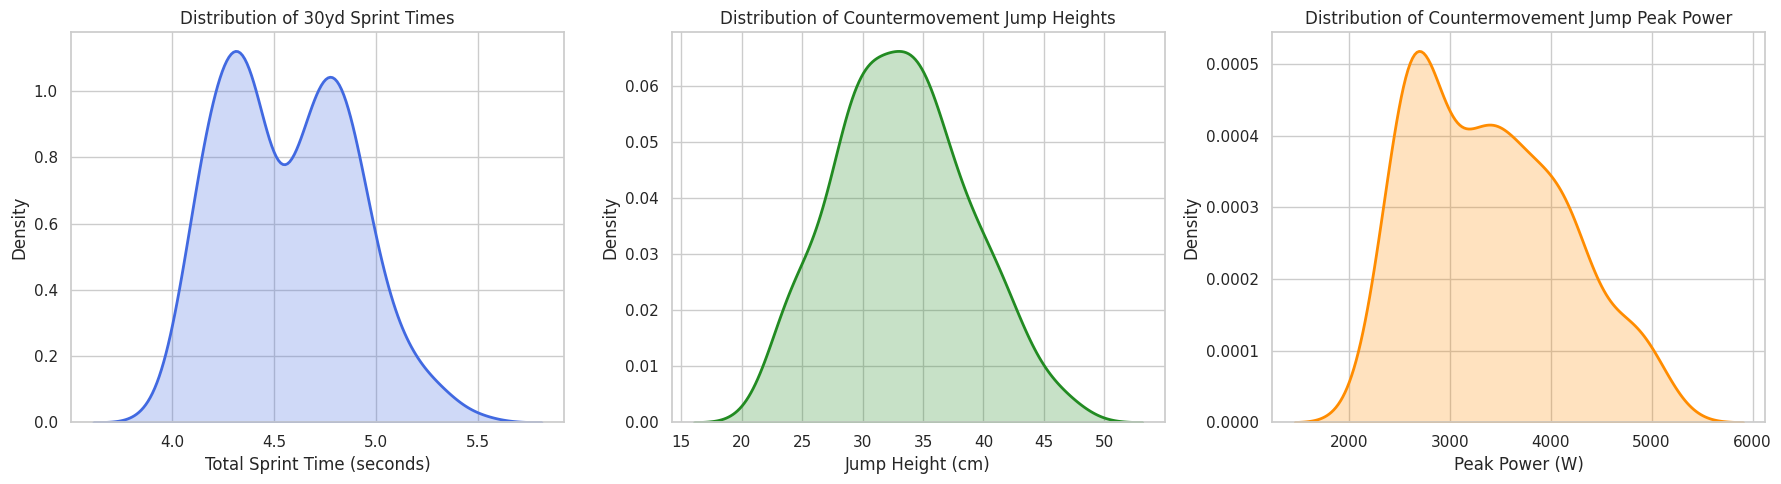

In [12]:
# =======================================
#  Code generated or assisted by Claude
# =======================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Density Plot for Sprint Time (Total)
sns.kdeplot(data=speed_df_cleaned, x='Total', fill=True, color='royalblue', ax=axes[0], lw=2)
axes[0].set_title('Distribution of 30yd Sprint Times')
axes[0].set_xlabel('Total Sprint Time (seconds)')
axes[0].set_ylabel('Density')

# 2. Density Plot for Jump Height
sns.kdeplot(data=cmj_df_cleaned, x='Jump Height (Imp-Mom) [cm] ', fill=True, color='forestgreen', ax=axes[1], lw=2)
axes[1].set_title('Distribution of Countermovement Jump Heights')
axes[1].set_xlabel('Jump Height (cm)')
axes[1].set_ylabel('Density')

# 3. Density Plot for Peak Power
sns.kdeplot(data=cmj_df_cleaned, x='Peak Power [W] ', fill=True, color='darkorange', ax=axes[2], lw=2)
axes[2].set_title('Distribution of Countermovement Jump Peak Power')
axes[2].set_xlabel('Peak Power (W)')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

## 📓Lab Note

Copy the box plot and paste it onto your lab write-up.

## 📊 Data Visualization: Bat Speed vs. Grip Strength

Let's visualize the relationship between **bat speed** and **grip strength** from `plnu_df_cleaned` using a scatter plot. This can help us understand if there's any correlation between these two variables.

###✋ GenAI prompt ###
Generate code that creates a scatter plot of bat speed and grip strength on the y and x axes, respectively. Add the coefficient of determination value and the regression line on the plot to indicate the strength of the high performance testing metric in predicting bat speed.

In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************


## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📊 Data Visualization: Bat Speed vs. IMTP Peak Force

Let's visualize the relationship between **bat speed** and **IMTP peak force** from `obp_df` using a scatter plot. This can help us understand if there's any correlation between these two variables.

###✋ GenAI prompt ###
Generate code that creates a scatter plot of bat speed and IMTP Peak Force on the y and x axes, respectively. Add the coefficient of determination value and regression line on the plot to indicate the strength of the high performance testing metric on bat speed.

In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************



## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📔 Final Notes ##

☝ Notice in these last couple of prompts, the actual names of the bat speed, grip strength, and IMTP force metrics were not used. By now, the AI agent knows the exact names of the variables of interest so there's no need to list them exactly in your prompts (but it helps!). Based on the plots and R^2 values, it looks IMTP force is more predictive of bat speed than grip strength!

💡 **What other high performance testing metrics can predict bat speed?**

Let's put your vibe code skills to the test and complete the lab by selecting two more potential bat speed predictors from either data frame using the same approach we did for grip strength and IMTP force. Use the above prompts and/or code to generate the scatter plots of your selected independent variables.




In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************